In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_test = 'test-english'
dataset_train = 'training-english'
dataset_valid = 'validation-english'

labels = 'values_labels'
# labels = 'subclasses_labels'

In [3]:
sentences_test_file_path = f"datasets/valueeval24/{dataset_test}/sentences.tsv"
sentences_train_file_path = f"datasets/valueeval24/{dataset_train}/sentences.tsv"
sentences_valid_file_path = f"datasets/valueeval24/{dataset_valid}/sentences.tsv"
labels_file_path_test = f"datasets/valueeval24/{dataset_test}/{labels}.tsv"
labels_file_path_train = f"datasets/valueeval24/{dataset_train}/{labels}.tsv"
labels_file_path_valid = f"datasets/valueeval24/{dataset_valid}/{labels}.tsv"

In [4]:
sentences_test_df = pd.read_csv(sentences_test_file_path, sep="\t")
sentences_train_df = pd.read_csv(sentences_train_file_path, sep="\t")
sentences_valid_df = pd.read_csv(sentences_valid_file_path, sep="\t")
labels_test_df = pd.read_csv(labels_file_path_test, sep="\t")
labels_train_df = pd.read_csv(labels_file_path_train, sep="\t")
labels_valid_df = pd.read_csv(labels_file_path_valid, sep="\t")
dataset_test_df = pd.merge(sentences_test_df, labels_test_df, on=["Text-ID", "Sentence-ID"])
dataset_train_df = pd.merge(sentences_train_df, labels_train_df, on=["Text-ID", "Sentence-ID"])
dataset_valid_df = pd.merge(sentences_valid_df, labels_valid_df, on=["Text-ID", "Sentence-ID"])

In [5]:
label_columns = labels_test_df.columns[2:]
label_counts_test = dataset_test_df[label_columns].apply(pd.Series.value_counts).T
label_counts_train = dataset_train_df[label_columns].apply(pd.Series.value_counts).T
label_counts_valid = dataset_valid_df[label_columns].apply(pd.Series.value_counts).T
# label_counts_test = label_counts_test.fillna(0)  # Fill NaN with 0 where necessary

label_counts_test.columns = ['count_0', 'count_1']
label_counts_train.columns = ['count_0', 'count_1']
label_counts_valid.columns = ['count_0', 'count_1']

label_counts_test['proportion_0'] = label_counts_test['count_0'] / label_counts_test['count_0'].sum()
label_counts_test['proportion_1'] = label_counts_test['count_1'] / label_counts_test['count_1'].sum()

label_counts_train['proportion_0'] = label_counts_train['count_0'] / label_counts_train['count_0'].sum()
label_counts_train['proportion_1'] = label_counts_train['count_1'] / label_counts_train['count_1'].sum()

label_counts_valid['proportion_0'] = label_counts_valid['count_0'] / label_counts_valid['count_0'].sum()
label_counts_valid['proportion_1'] = label_counts_valid['count_1'] / label_counts_valid['count_1'].sum()

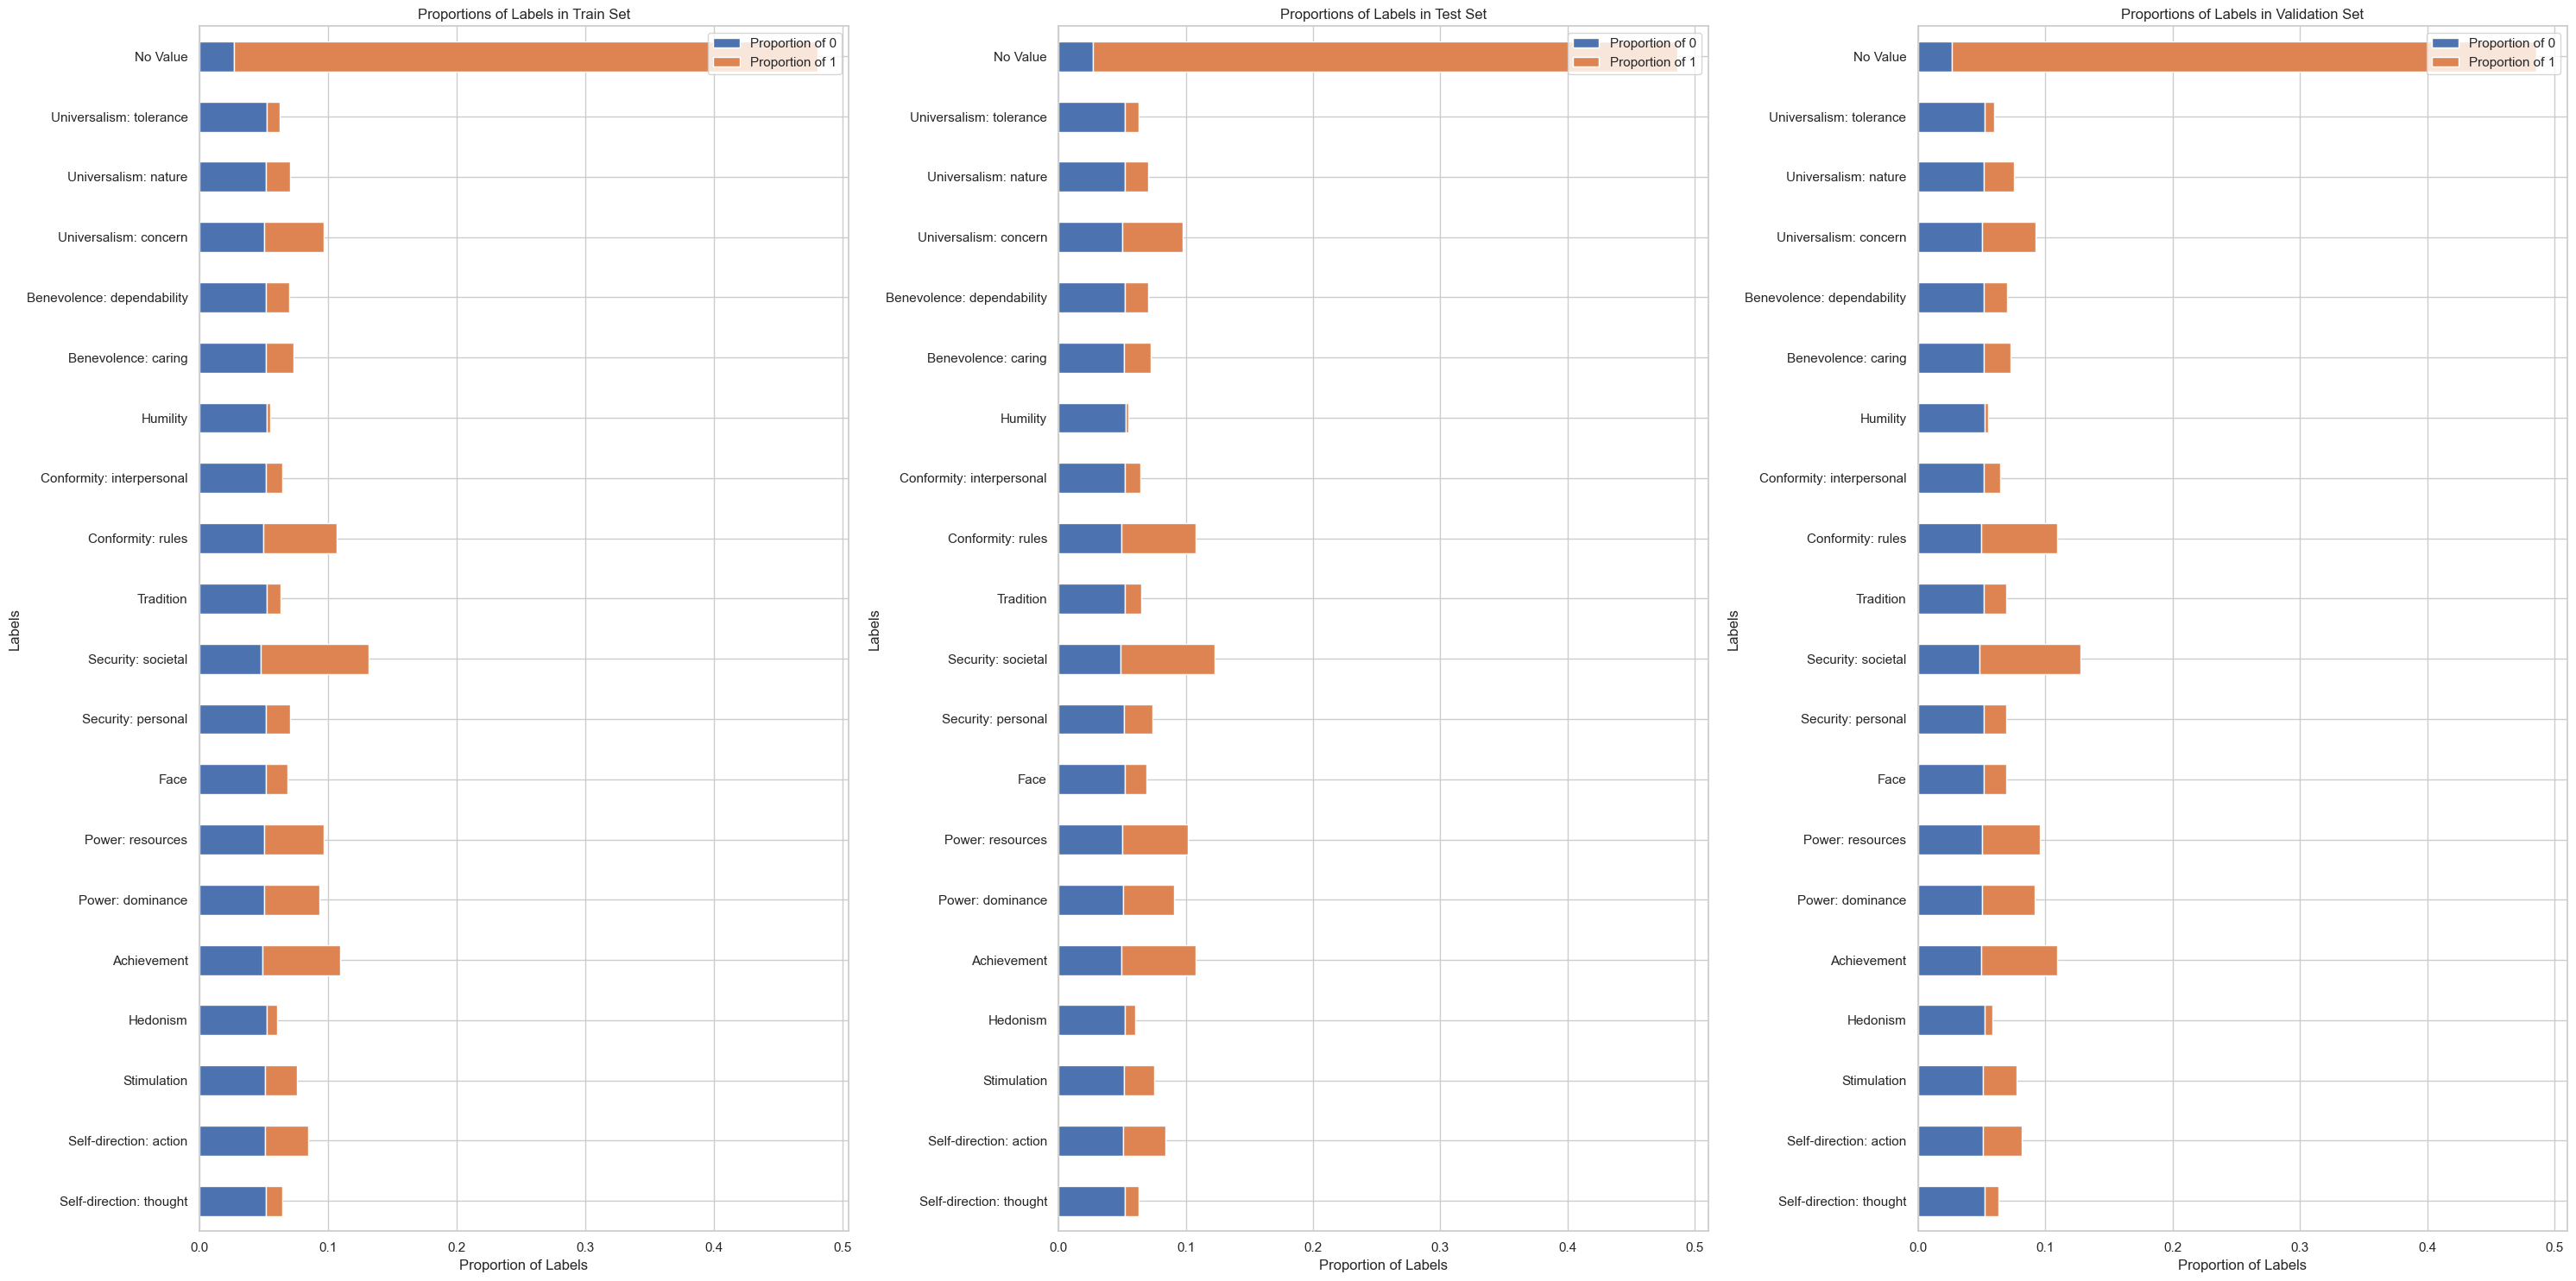

In [6]:
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(30, 15))

# List of the dataframes to plot
label_counts_dfs = [label_counts_train, label_counts_test, label_counts_valid]
titles = ['Train Set', 'Test Set', 'Validation Set']

# Loop through each dataframe and plot it on the respective subplot
for i, label_counts in enumerate(label_counts_dfs):
    # Plot the proportions of 1's and 0's for each label in the current dataset
    label_counts[['proportion_0', 'proportion_1']].plot(kind='barh', stacked=True, ax=axes[i])
    
    # Set the title and labels for the subplot
    axes[i].set_title(f'Proportions of Labels in {titles[i]}')
    axes[i].set_xlabel('Proportion of Labels')
    axes[i].set_ylabel('Labels')
    axes[i].legend(["Proportion of 0", "Proportion of 1"], loc="upper right")

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [10]:
label_counts_train

,count_0,count_1,proportion_0,proportion_1
Openness to change,41088,3670,0.234042,0.076091
Self-enhancement,36689,8069,0.208985,0.167296
Conservation,35404,9354,0.201666,0.193938
Self-transcendence,39315,5443,0.223943,0.112850
no_value,23062,21696,0.131364,0.449826
